# IMPORT DATA


Superclasses enumerated by dataset description are as follows:
```
Records | Superclass | Description
9528 | NORM | Normal ECG
5486 | MI | Myocardial Infarction
5250 | STTC | ST/T Change
4907 | CD | Conduction Disturbance
2655 | HYP | Hypertrophy
```

In [1]:
import os
import ast
import wfdb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow.keras as keras

sns.set_style('darkgrid')

## DATA LOADING 

In [2]:
PATH_TO_DATA = 'D:\SMTR 7\Koding\Skripsi\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3'

# Load data
ECG_df = pd.read_csv(os.path.join(PATH_TO_DATA, 'ptbxl_database.csv'), index_col='ecg_id')
ECG_df.scp_codes = ECG_df.scp_codes.apply(lambda x: ast.literal_eval(x))
ECG_df.patient_id = ECG_df.patient_id.astype(int)
ECG_df.nurse = ECG_df.nurse.astype('Int64')
ECG_df.site = ECG_df.site.astype('Int64')
ECG_df.validated_by = ECG_df.validated_by.astype('Int64')

# Load SCP statements
SCP_df = pd.read_csv(os.path.join(PATH_TO_DATA, 'scp_statements.csv'), index_col=0)
SCP_df = SCP_df[SCP_df.diagnostic == 1]

ECG_df

,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709,56.0,1,NaN,63.0,2,0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243,19.0,0,NaN,70.0,2,0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372,37.0,1,NaN,69.0,2,0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014,24.0,0,NaN,82.0,2,0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448,19.0,1,NaN,70.0,2,0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21833,17180,67.0,1,NaN,NaN,1,2,AT-60 3,2001-05-31 09:14:35,ventrikulÄre extrasystole(n) sinustachykardie ...,...,True,NaN,", alles,",NaN,NaN,1ES,NaN,7,records100/21000/21833_lr,records500/21000/21833_hr
21834,20703,300.0,0,NaN,NaN,1,2,AT-60 3,2001-06-05 11:33:39,sinusrhythmus lagetyp normal qrs(t) abnorm ...,...,True,NaN,NaN,NaN,NaN,NaN,NaN,4,records100/21000/21834_lr,records500/21000/21834_hr
21835,19311,59.0,1,NaN,NaN,1,2,AT-60 3,2001-06-08 10:30:27,sinusrhythmus lagetyp normal t abnorm in anter...,...,True,NaN,", I-AVR,",NaN,NaN,NaN,NaN,2,records100/21000/21835_lr,records500/21000/21835_hr


In [3]:
# Get diagnostics subclass
def diagnostic_subclass(scp):
    res = set()
    for k in scp.keys():
        if k in SCP_df.index:
            res.add(SCP_df.loc[k].diagnostic_subclass)
    return list(res)
                    
ECG_df['scp_subclasses'] = ECG_df.scp_codes.apply(diagnostic_subclass)

## Filtering

In [4]:
# Membuat list subclass yang diinginkan
selected_subclasses = ['NORM', 'PMI', 'LMI', 'AMI', 'IMI']

# Melakukan filtering
filtered_ECG_df = ECG_df[ECG_df['scp_subclasses'].apply(lambda x: any(subclass in x for subclass in selected_subclasses))]

In [5]:
filtered_ECG_df.shape

(14982, 28)

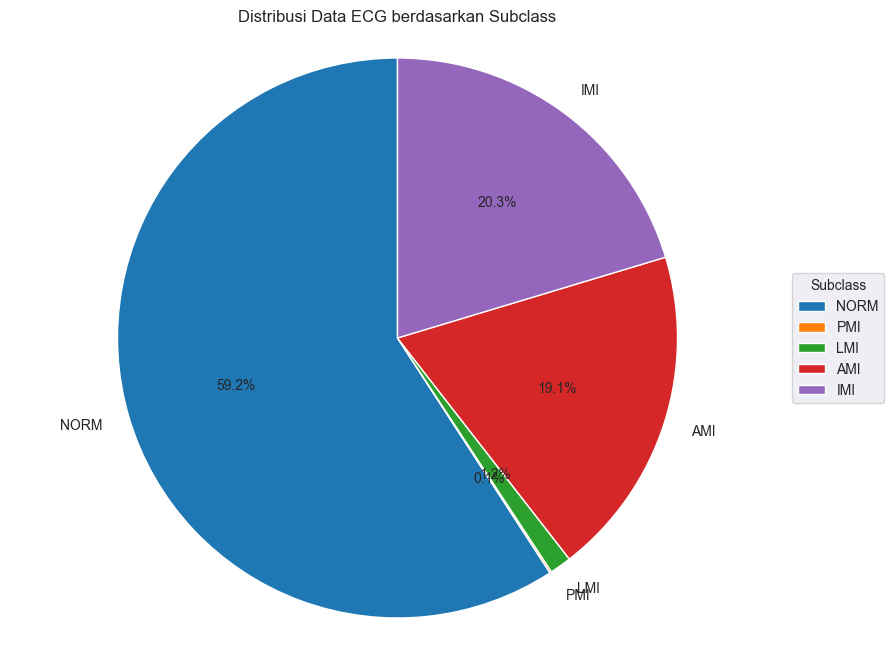


Jumlah data untuk setiap subclass:
NORM: 9514 data
PMI: 17 data
LMI: 201 data
AMI: 3078 data
IMI: 3271 data

Total keseluruhan data: 16081 data


In [6]:
# Menghitung jumlah data untuk setiap subclass
subclass_counts = {}
for subclass in selected_subclasses:
    count = len(filtered_ECG_df[filtered_ECG_df['scp_subclasses'].apply(lambda x: subclass in x)])
    subclass_counts[subclass] = count

# Membuat pie chart
plt.figure(figsize=(10, 8))
plt.pie(subclass_counts.values(), 
        labels=subclass_counts.keys(),
        autopct='%1.1f%%',
        startangle=90)
plt.title('Distribusi Data ECG berdasarkan Subclass')

# Menambahkan legend
plt.legend(title="Subclass", 
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.axis('equal')
plt.show()

# Menampilkan jumlah data dalam bentuk tabel
print("\nJumlah data untuk setiap subclass:")
for subclass, count in subclass_counts.items():
    print(f"{subclass}: {count} data")

print(f"\nTotal keseluruhan data: {sum(subclass_counts.values())} data")

## Load RawData

In [7]:
def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(os.path.join(path, f)) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(os.path.join(path, f)) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data

sampling_rate = 100

ECG_data = load_raw_data(filtered_ECG_df, sampling_rate, PATH_TO_DATA)

ECG_data.shape

(14982, 1000, 12)

# DATA PREPARATION

## Fake Data using GAN

Shape PMI train: (168, 1000, 1)
Shape LMI train: (1932, 1000, 1)


c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training GAN untuk PMI data:
Epoch 0, G Loss: 0.6847, D Loss: 1.3992
Epoch 10, G Loss: 0.7941, D Loss: 1.2510
Epoch 20, G Loss: 0.8569, D Loss: 1.3183
Epoch 30, G Loss: 0.8145, D Loss: 1.2855
Epoch 40, G Loss: 0.7416, D Loss: 1.3374
Epoch 50, G Loss: 0.7494, D Loss: 1.2855
Epoch 60, G Loss: 0.5940, D Loss: 1.4096
Epoch 70, G Loss: 0.8767, D Loss: 1.2113
Epoch 80, G Loss: 0.6604, D Loss: 1.2914
Epoch 90, G Loss: 0.8308, D Loss: 1.1749
Epoch 100, G Loss: 0.7520, D Loss: 1.2665
Epoch 110, G Loss: 0.6636, D Loss: 1.2973
Epoch 120, G Loss: 0.8373, D Loss: 1.1125
Epoch 130, G Loss: 0.7232, D Loss: 1.3126
Epoch 140, G Loss: 0.5891, D Loss: 1.4660
Epoch 150, G Loss: 0.8577, D Loss: 1.2289
Epoch 160, G Loss: 0.8105, D Loss: 1.0845
Epoch 170, G Loss: 0.6585, D Loss: 1.4570
Epoch 180, G Loss: 0.8481, D Loss: 1.2000
Epoch 190, G Loss: 0.7825, D Loss: 1.0784
Epoch 200, G Loss: 0.6598, D Loss: 1.5547
Epoch 210, G Loss: 0.8075, D Loss: 1.2322
Epoch 220, G Loss: 0.8626, D Loss: 1.2645
Epoch 230, G Los

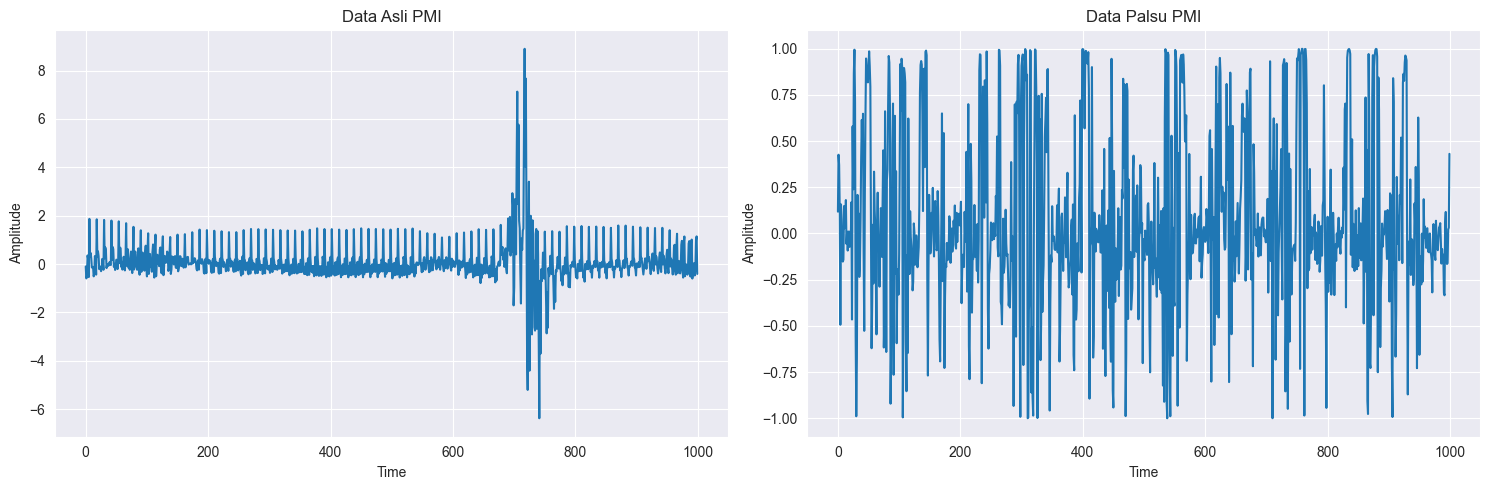

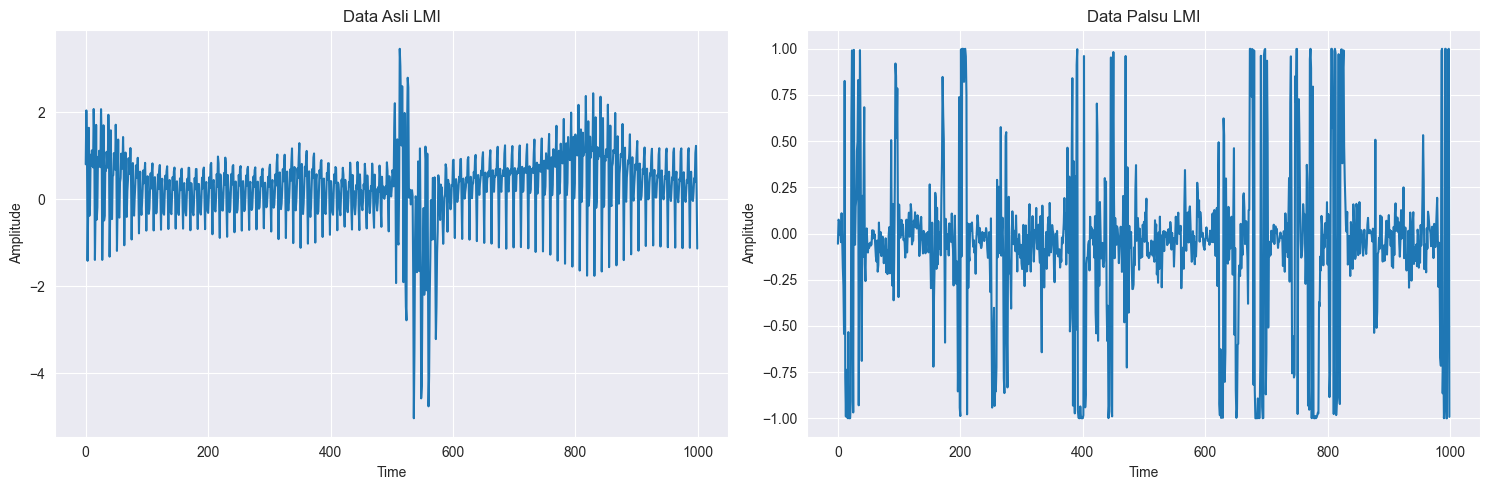


Informasi jumlah data:
PMI asli - Training: 168, Testing: 36
PMI palsu: 3000
LMI asli - Training: 1932, Testing: 480
LMI palsu: 3000


In [8]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# Memisahkan data PMI dan LMI
pmi_data = ECG_data[filtered_ECG_df['scp_subclasses'].apply(lambda x: 'PMI' in x)]
lmi_data = ECG_data[filtered_ECG_df['scp_subclasses'].apply(lambda x: 'LMI' in x)]

# Fungsi untuk membagi data
def split_data(data, test_size=0.2):
    n_samples = len(data)
    n_test = int(n_samples * test_size)
    
    indices = np.random.permutation(n_samples)
    test_idx = indices[:n_test]
    train_idx = indices[n_test:]
    
    return data[train_idx], data[test_idx]

# Membagi data menjadi train dan test
pmi_train, pmi_test = split_data(pmi_data)
lmi_train, lmi_test = split_data(lmi_data)

# Preprocessing
def preprocess_data(data):
    data = (data - np.mean(data)) / np.std(data)
    return data.reshape(-1, data.shape[1], 1)

# Preprocess data train dan test
pmi_train_processed = preprocess_data(pmi_train)
pmi_test_processed = preprocess_data(pmi_test)
lmi_train_processed = preprocess_data(lmi_train)
lmi_test_processed = preprocess_data(lmi_test)

# Print info shape data
print("Shape PMI train:", pmi_train_processed.shape)
print("Shape LMI train:", lmi_train_processed.shape)

# Generator model
def build_generator():
    model = keras.Sequential([
        keras.layers.Dense(250 * 4, input_shape=(100,)),
        keras.layers.Reshape((250, 4)),
        
        keras.layers.Conv1D(128, kernel_size=3, padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.LeakyReLU(alpha=0.2),
        
        keras.layers.UpSampling1D(2),
        keras.layers.Conv1D(64, kernel_size=3, padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.LeakyReLU(alpha=0.2),
        
        keras.layers.UpSampling1D(2),
        keras.layers.Conv1D(32, kernel_size=3, padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.LeakyReLU(alpha=0.2),
        
        keras.layers.Conv1D(1, kernel_size=3, padding='same', activation='tanh')
    ])
    return model

# Discriminator model
def build_discriminator():
    model = keras.Sequential([
        keras.layers.Conv1D(64, kernel_size=3, strides=2, padding='same', 
                           input_shape=(1000, 1)),
        keras.layers.LeakyReLU(alpha=0.2),
        keras.layers.Dropout(0.3),
        
        keras.layers.Conv1D(128, kernel_size=3, strides=2, padding='same'),
        keras.layers.LeakyReLU(alpha=0.2),
        keras.layers.Dropout(0.3),
        
        keras.layers.Flatten(),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

# Fungsi training
def train_gan(generator, discriminator, train_data, target_samples=3000, epochs=500, batch_size=16):
    # Optimizers
    generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
    discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
    
    # Loss function
    cross_entropy = tf.keras.losses.BinaryCrossentropy()
    
    @tf.function
    def train_step(real_signals):
        batch_size = tf.shape(real_signals)[0]
        noise = tf.random.normal([batch_size, 100])
        
        with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
            generated_signals = generator(noise, training=True)
            
            real_output = discriminator(real_signals, training=True)
            fake_output = discriminator(generated_signals, training=True)
            
            gen_loss = cross_entropy(tf.ones_like(fake_output), fake_output)
            real_loss = cross_entropy(tf.ones_like(real_output), real_output)
            fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
            disc_loss = real_loss + fake_loss
            
        gen_gradients = gen_tape.gradient(gen_loss, generator.trainable_variables)
        disc_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
        
        generator_optimizer.apply_gradients(zip(gen_gradients, generator.trainable_variables))
        discriminator_optimizer.apply_gradients(zip(disc_gradients, discriminator.trainable_variables))
        
        return gen_loss, disc_loss

    generated_samples = []
    
    # Training loop
    for epoch in range(epochs):
        idx = np.random.randint(0, train_data.shape[0], batch_size)
        real_batch = train_data[idx]
        
        g_loss, d_loss = train_step(real_batch)
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch}, G Loss: {g_loss:.4f}, D Loss: {d_loss:.4f}")
    
    # Generate samples until we reach target number
    remaining_samples = target_samples
    batch_size = 32  # Larger batch size for generation
    
    while remaining_samples > 0:
        current_batch = min(batch_size, remaining_samples)
        noise = tf.random.normal([current_batch, 100])
        generated = generator(noise, training=False)
        generated_samples.append(generated.numpy())
        remaining_samples -= current_batch
        
        # Print progress
        print(f"Generated {len(generated_samples) * batch_size} samples out of {target_samples}")
    
    return np.concatenate(generated_samples)[:target_samples]

# Fungsi visualisasi
def plot_comparison(real_data, fake_data, title):
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(real_data[0].reshape(-1))
    plt.title(f'Data Asli {title}')
    plt.xlabel('Time')
    plt.ylabel('Amplitude')
    
    plt.subplot(1, 2, 2)
    plt.plot(fake_data[0].reshape(-1))
    plt.title(f'Data Palsu {title}')
    plt.xlabel('Time')
    plt.ylabel('Amplitude')
    
    plt.tight_layout()
    plt.show()

# Build models
generator = build_generator()
discriminator = build_discriminator()

# Training PMI
print("Training GAN untuk PMI data:")
pmi_fake = train_gan(generator, discriminator, pmi_train_processed, target_samples=3000)

# Training LMI
print("\nTraining GAN untuk LMI data:")
lmi_fake = train_gan(generator, discriminator, lmi_train_processed, target_samples=3000)

# Visualisasi hasil
plot_comparison(pmi_train_processed, pmi_fake, "PMI")
plot_comparison(lmi_train_processed, lmi_fake, "LMI")

# Informasi jumlah data
print("\nInformasi jumlah data:")
print(f"PMI asli - Training: {len(pmi_train_processed)}, Testing: {len(pmi_test_processed)}")
print(f"PMI palsu: {len(pmi_fake)}")
print(f"LMI asli - Training: {len(lmi_train_processed)}, Testing: {len(lmi_test_processed)}")
print(f"LMI palsu: {len(lmi_fake)}")

# Save generated data (optional)
np.save('pmi_fake_data.npy', pmi_fake)
np.save('lmi_fake_data.npy', lmi_fake)

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split

# Function to prepare labels for the data
def prepare_labels(data_dict):
    labels = []
    combined_data = []
    
    for label, data in data_dict.items():
        n_samples = len(data)
        labels.extend([label] * n_samples)
        combined_data.append(data)
    
    return np.concatenate(combined_data), np.array(labels)

# Let's first check the shapes of our data
print("Original shapes:")
print("LMI fake shape:", lmi_fake.shape)
print("PMI fake shape:", pmi_fake.shape)
print("Real ECG data shape:", ECG_data.shape)

# Reshape GAN-generated data to match real data dimensions
# We'll duplicate the single channel 12 times
def reshape_gan_data(gan_data):
    # First reshape back to (n_samples, timesteps)
    n_samples = gan_data.shape[0]
    timesteps = 1000  # Based on your original data
    reshaped = gan_data.reshape(n_samples, timesteps)
    
    # Create 12 copies of the channel
    multi_channel = np.stack([reshaped] * 12, axis=-1)
    return multi_channel

# Reshape GAN data
lmi_fake_reshaped = reshape_gan_data(lmi_fake)
pmi_fake_reshaped = reshape_gan_data(pmi_fake)

print("\nAfter reshaping:")
print("LMI fake reshaped shape:", lmi_fake_reshaped.shape)
print("PMI fake reshaped shape:", pmi_fake_reshaped.shape)

# Prepare real data dictionary
real_data = {
    'NORM': ECG_data[filtered_ECG_df['scp_subclasses'].apply(lambda x: 'NORM' in x)],
    'AMI': ECG_data[filtered_ECG_df['scp_subclasses'].apply(lambda x: 'AMI' in x)],
    'IMI': ECG_data[filtered_ECG_df['scp_subclasses'].apply(lambda x: 'IMI' in x)],
    'LMI': ECG_data[filtered_ECG_df['scp_subclasses'].apply(lambda x: 'LMI' in x)],
    'PMI': ECG_data[filtered_ECG_df['scp_subclasses'].apply(lambda x: 'PMI' in x)]
}

# Add GAN-generated data
real_data['LMI'] = np.concatenate([real_data['LMI'], lmi_fake_reshaped])
real_data['PMI'] = np.concatenate([real_data['PMI'], pmi_fake_reshaped])

# Prepare the combined dataset
X, y = prepare_labels(real_data)

# Preprocess the data
# Normalize each channel independently
X_processed = np.zeros_like(X, dtype=np.float32)
for i in range(12):
    X_processed[:, :, i] = (X[:, :, i] - np.mean(X[:, :, i])) / np.std(X[:, :, i])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Print information about the dataset
print("\nDataset Information:")
print("===================")
print(f"Total number of samples: {len(X)}")
print("Input shape:", X.shape)

print("\nClass distribution in complete dataset:")
for label in np.unique(y):
    count = np.sum(y == label)
    percentage = (count / len(y)) * 100
    print(f"{label}: {count} samples ({percentage:.2f}%)")

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nClass distribution in training set:")
for label in np.unique(y_train):
    count = np.sum(y_train == label)
    percentage = (count / len(y_train)) * 100
    print(f"{label}: {count} samples ({percentage:.2f}%)")

print("\nClass distribution in testing set:")
for label in np.unique(y_test):
    count = np.sum(y_test == label)
    percentage = (count / len(y_test)) * 100
    print(f"{label}: {count} samples ({percentage:.2f}%)")

# Save the processed datasets (optional)
np.save('X_train.npy', X_train)
np.save('X_test.npy', X_test)
np.save('y_train.npy', y_train)
np.save('y_test.npy', y_test)

Original shapes:
LMI fake shape: (3000, 1000, 1)
PMI fake shape: (3000, 1000, 1)
Real ECG data shape: (14982, 1000, 12)

After reshaping:
LMI fake reshaped shape: (3000, 1000, 12)
PMI fake reshaped shape: (3000, 1000, 12)

Dataset Information:
Total number of samples: 22081
Input shape: (22081, 1000, 12)

Class distribution in complete dataset:
AMI: 3078 samples (13.94%)
IMI: 3271 samples (14.81%)
LMI: 3201 samples (14.50%)
NORM: 9514 samples (43.09%)
PMI: 3017 samples (13.66%)

Training set shape: (17664, 1000, 12)
Testing set shape: (4417, 1000, 12)

Class distribution in training set:
AMI: 2462 samples (13.94%)
IMI: 2617 samples (14.82%)
LMI: 2561 samples (14.50%)
NORM: 7611 samples (43.09%)
PMI: 2413 samples (13.66%)

Class distribution in testing set:
AMI: 616 samples (13.95%)
IMI: 654 samples (14.81%)
LMI: 640 samples (14.49%)
NORM: 1903 samples (43.08%)
PMI: 604 samples (13.67%)


## Hasil GAN

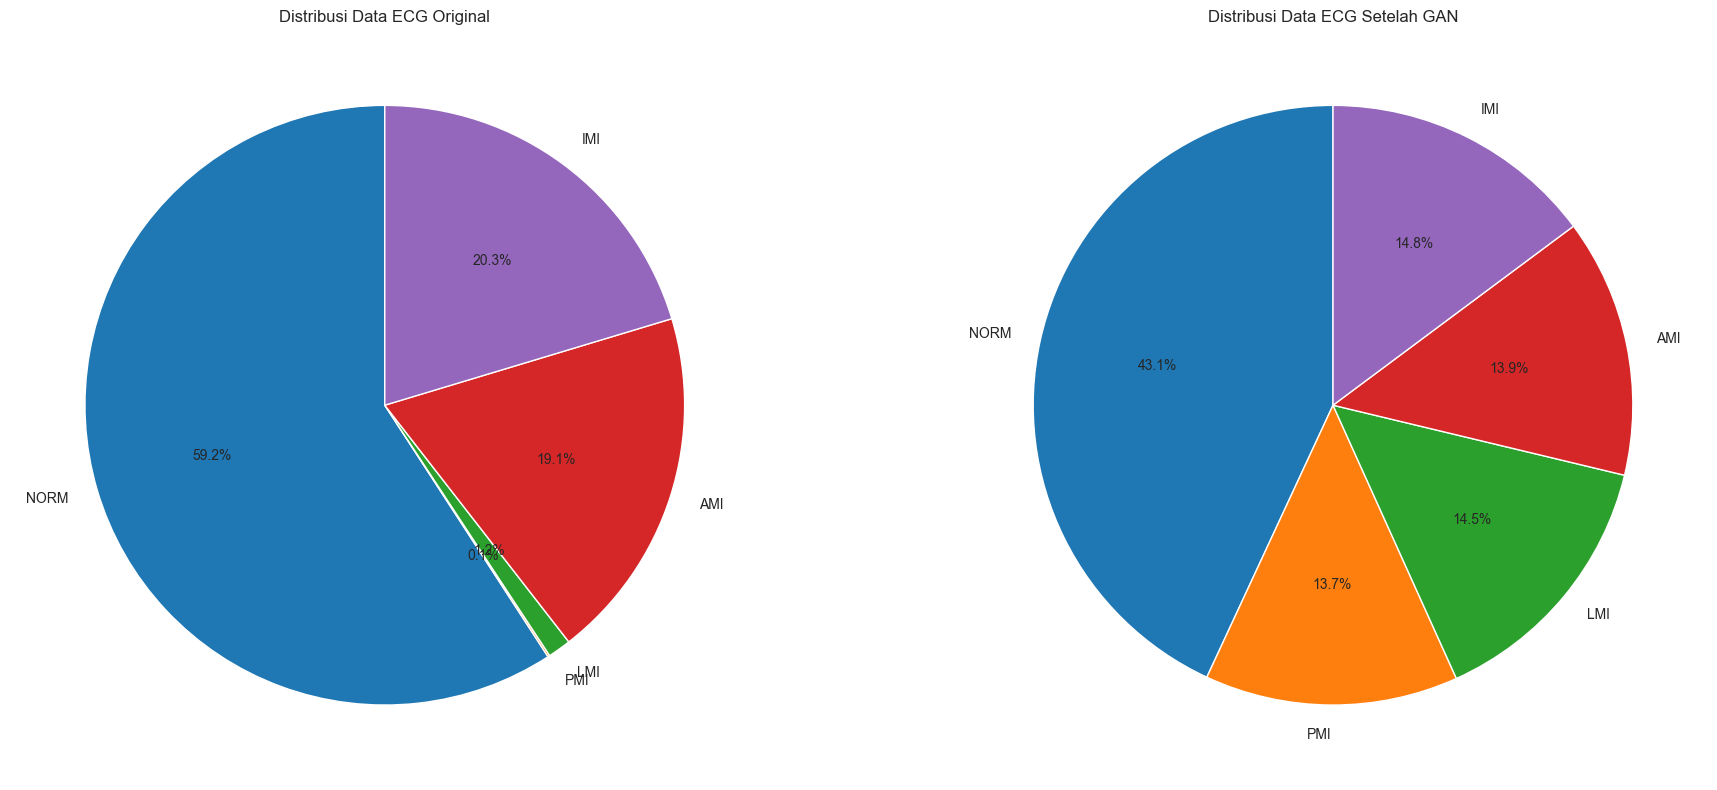


Jumlah data untuk setiap subclass:

Data Original:
NORM: 9514 data
PMI: 17 data
LMI: 201 data
AMI: 3078 data
IMI: 3271 data

Data Setelah GAN:
NORM: 9514 data
PMI: 3017 data
LMI: 3201 data
AMI: 3078 data
IMI: 3271 data

Jumlah data yang ditambahkan oleh GAN:
PMI: 3000 data
LMI: 3000 data

Persentase peningkatan data:
PMI: 17647.1%
LMI: 1492.5%


In [10]:
# Menghitung jumlah data untuk setiap subclass (data asli)
def count_original_data(filtered_df, subclasses):
    counts = {}
    for subclass in subclasses:
        count = len(filtered_df[filtered_df['scp_subclasses'].apply(lambda x: subclass in x)])
        counts[subclass] = count
    return counts

# Hitung jumlah data asli
original_counts = count_original_data(filtered_ECG_df, selected_subclasses)

# Hitung jumlah data setelah GAN
# Asumsikan kita memiliki data palsu untuk PMI dan LMI
gan_counts = original_counts.copy()
gan_counts['PMI'] += len(pmi_fake)  # Tambahkan jumlah data PMI palsu
gan_counts['LMI'] += len(lmi_fake)  # Tambahkan jumlah data LMI palsu

# Membuat subplot untuk membandingkan distribusi sebelum dan sesudah GAN
plt.figure(figsize=(20, 8))

# Pie chart untuk data asli
plt.subplot(1, 2, 1)
plt.pie(original_counts.values(), 
        labels=original_counts.keys(),
        autopct='%1.1f%%',
        startangle=90)
plt.title('Distribusi Data ECG Original')

# Pie chart untuk data setelah GAN
plt.subplot(1, 2, 2)
plt.pie(gan_counts.values(), 
        labels=gan_counts.keys(),
        autopct='%1.1f%%',
        startangle=90)
plt.title('Distribusi Data ECG Setelah GAN')

plt.tight_layout()
plt.show()

# Menampilkan jumlah data dalam bentuk tabel
print("\nJumlah data untuk setiap subclass:")
print("\nData Original:")
for subclass, count in original_counts.items():
    print(f"{subclass}: {count} data")

print("\nData Setelah GAN:")
for subclass, count in gan_counts.items():
    print(f"{subclass}: {count} data")

print("\nJumlah data yang ditambahkan oleh GAN:")
print(f"PMI: {len(pmi_fake)} data")
print(f"LMI: {len(lmi_fake)} data")

# Menghitung persentase peningkatan
pmi_increase = (gan_counts['PMI'] - original_counts['PMI']) / original_counts['PMI'] * 100
lmi_increase = (gan_counts['LMI'] - original_counts['LMI']) / original_counts['LMI'] * 100

print(f"\nPersentase peningkatan data:")
print(f"PMI: {pmi_increase:.1f}%")
print(f"LMI: {lmi_increase:.1f}%")


Informasi Dataset Final:

PMI:
Training (asli + palsu): 3168 sampel
- Data asli: 168 sampel
- Data palsu: 3000 sampel
Testing (hanya asli): 36 sampel

LMI:
Training (asli + palsu): 4932 sampel
- Data asli: 1932 sampel
- Data palsu: 3000 sampel
Testing (hanya asli): 480 sampel


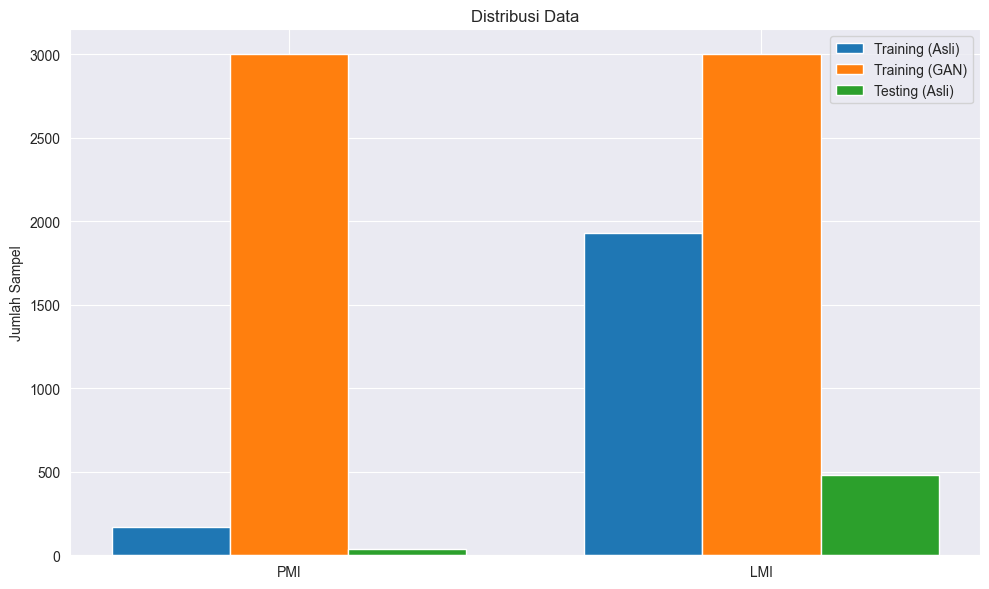

In [11]:
# Menggabungkan data asli dan data palsu untuk training
def combine_data_for_training(real_train, fake_data):
    # Menggabungkan data training asli dengan data palsu
    combined_train = np.concatenate([real_train, fake_data])
    return combined_train

# Fungsi untuk membuat dataset final
def prepare_final_dataset():
    # Data Training = Data training asli + Data GAN
    pmi_combined_train = combine_data_for_training(pmi_train_processed, pmi_fake)
    lmi_combined_train = combine_data_for_training(lmi_train_processed, lmi_fake)
    
    # Data Testing = Hanya data testing asli
    pmi_final_test = pmi_test_processed
    lmi_final_test = lmi_test_processed
    
    # Print informasi dataset
    print("\nInformasi Dataset Final:")
    print("\nPMI:")
    print(f"Training (asli + palsu): {len(pmi_combined_train)} sampel")
    print(f"- Data asli: {len(pmi_train_processed)} sampel")
    print(f"- Data palsu: {len(pmi_fake)} sampel")
    print(f"Testing (hanya asli): {len(pmi_final_test)} sampel")
    
    print("\nLMI:")
    print(f"Training (asli + palsu): {len(lmi_combined_train)} sampel")
    print(f"- Data asli: {len(lmi_train_processed)} sampel")
    print(f"- Data palsu: {len(lmi_fake)} sampel")
    print(f"Testing (hanya asli): {len(lmi_final_test)} sampel")
    
    return {
        'pmi_train': pmi_combined_train,
        'pmi_test': pmi_final_test,
        'lmi_train': lmi_combined_train,
        'lmi_test': lmi_final_test
    }

# Membuat dataset final
final_dataset = prepare_final_dataset()

# Optional: Simpan dataset
np.save('pmi_train_final.npy', final_dataset['pmi_train'])
np.save('pmi_test_final.npy', final_dataset['pmi_test'])
np.save('lmi_train_final.npy', final_dataset['lmi_train'])
np.save('lmi_test_final.npy', final_dataset['lmi_test'])

# Visualisasi distribusi data
def plot_data_distribution():
    labels = ['PMI', 'LMI']
    train_real = [len(pmi_train_processed), len(lmi_train_processed)]
    train_fake = [len(pmi_fake), len(lmi_fake)]
    test_data = [len(final_dataset['pmi_test']), len(final_dataset['lmi_test'])]
    
    x = np.arange(len(labels))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width, train_real, width, label='Training (Asli)')
    rects2 = ax.bar(x, train_fake, width, label='Training (GAN)')
    rects3 = ax.bar(x + width, test_data, width, label='Testing (Asli)')
    
    ax.set_ylabel('Jumlah Sampel')
    ax.set_title('Distribusi Data')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    
    plt.tight_layout()
    plt.show()

# Tampilkan visualisasi
plot_data_distribution()

In [12]:
print("Shape data:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Shape data:
X_train shape: (17664, 1000, 12)
y_train shape: (17664,)
X_test shape: (4417, 1000, 12)
y_test shape: (4417,)


# MODEL

## CNN model

In [13]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, KFold
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import os

# Buat folder untuk menyimpan hasil setiap fold
if not os.path.exists('fold_results'):
    os.makedirs('fold_results')

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_train)
y_train_cat = to_categorical(y_encoded)

y_test_encoded = le.transform(y_test)
y_test_cat = to_categorical(y_test_encoded)

def build_cnn_model(input_shape, num_classes=5):
    model = Sequential([
        # First Convolutional Layer
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        
        # Second Convolutional Layer
        Conv1D(filters=128, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        
        # Third Convolutional Layer
        Conv1D(filters=256, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        
        # Flatten layer
        Flatten(),
        
        # Dense layers
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    
    optimizer = Adam(learning_rate=0.001)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

def get_callbacks(fold):
    fold_dir = f'fold_results/fold_{fold}'
    if not os.path.exists(fold_dir):
        os.makedirs(fold_dir)
        
    return [
        ModelCheckpoint(
            f'{fold_dir}/best_cnn_model_5class.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1,
            mode='max'
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=0.00001,
            verbose=1
        )
    ]

def plot_training_history(history, fold, save_dir):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot accuracy
    ax1.plot(history.history['accuracy'])
    ax1.plot(history.history['val_accuracy'])
    ax1.set_title(f'Model Accuracy - Fold {fold}')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend(['Train', 'Validation'])
    
    # Plot loss
    ax2.plot(history.history['loss'])
    ax2.plot(history.history['val_loss'])
    ax2.set_title(f'Model Loss - Fold {fold}')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend(['Train', 'Validation'])
    
    plt.tight_layout()
    plt.savefig(f'{save_dir}/training_history.png')
    plt.close()

def evaluate_model(model, X_test, y_test, class_names, fold, save_dir):
    # Prediksi
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_test_classes = np.argmax(y_test, axis=1)
    
    # Metrics
    accuracy = accuracy_score(y_test_classes, y_pred_classes)
    precision = precision_score(y_test_classes, y_pred_classes, average='weighted')
    recall = recall_score(y_test_classes, y_pred_classes, average='weighted')
    f1 = f1_score(y_test_classes, y_pred_classes, average='weighted')
    
    # Save metrics to file
    with open(f'{save_dir}/evaluation_metrics.txt', 'w', encoding='utf-8') as f:
        f.write(f"Fold {fold} Evaluation Metrics:\n")
        f.write(f"Accuracy: {accuracy:.4f}\n")
        f.write(f"Precision: {precision:.4f}\n")
        f.write(f"Recall: {recall:.4f}\n")
        f.write(f"F1-Score: {f1:.4f}\n")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test_classes, y_pred_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.savefig(f'{save_dir}/confusion_matrix.png')
    plt.close()
    
    # Save confusion matrix as CSV
    cm_df = pd.DataFrame(cm, 
                        index=class_names,
                        columns=class_names)
    cm_df.to_csv(f'{save_dir}/confusion_matrix.csv')
    
    # Per-class metrics
    per_class_metrics = []
    for i, class_name in enumerate(class_names):
        class_precision = precision_score(y_test_classes, y_pred_classes, average=None)[i]
        class_recall = recall_score(y_test_classes, y_pred_classes, average=None)[i]
        class_f1 = f1_score(y_test_classes, y_pred_classes, average=None)[i]
        
        tp = cm[i, i]
        fp = np.sum(cm[:, i]) - tp
        fn = np.sum(cm[i, :]) - tp
        tn = np.sum(cm) - tp - fp - fn
        specificity = tn/(tn+fp)
        
        per_class_metrics.append({
            'Class': class_name,
            'True Positives': tp,
            'True Negatives': tn,
            'False Positives': fp,
            'False Negatives': fn,
            'Precision': class_precision,
            'Recall': class_recall,
            'F1-Score': class_f1,
            'Specificity': specificity
        })
    
    # Save per-class metrics
    pd.DataFrame(per_class_metrics).to_csv(f'{save_dir}/per_class_metrics.csv', index=False)
    
    with open(f'{save_dir}/per_class_metrics.txt', 'w', encoding='utf-8') as f:
        for metrics in per_class_metrics:
            f.write(f"\n{metrics['Class']}:\n")
            f.write(f"True Positives (TP): {metrics['True Positives']}\n")
            f.write(f"True Negatives (TN): {metrics['True Negatives']}\n")
            f.write(f"False Positives (FP): {metrics['False Positives']}\n")
            f.write(f"False Negatives (FN): {metrics['False Negatives']}\n")
            f.write(f"Precision: {metrics['Precision']:.4f}\n")
            f.write(f"Recall: {metrics['Recall']:.4f}\n")
            f.write(f"F1-Score: {metrics['F1-Score']:.4f}\n")
            f.write(f"Specificity: {metrics['Specificity']:.4f}\n")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm,
        'confusion_matrix_df': cm_df,
        'per_class_metrics': per_class_metrics
    }

# Inisialisasi K-Fold
n_folds = 5
kfold = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# List untuk menyimpan hasil setiap fold
fold_histories = []
fold_results = []

# K-Fold Cross Validation
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train)):
    fold_num = fold + 1
    print(f'\nFold {fold_num}/{n_folds}')
    fold_dir = f'fold_results/fold_{fold_num}'
    
    # Split data untuk fold ini
    X_train_fold = X_train[train_idx]
    y_train_fold = y_train_cat[train_idx]
    X_val_fold = X_train[val_idx]
    y_val_fold = y_train_cat[val_idx]
    
    # Build model
    input_shape = (X_train.shape[1], X_train.shape[2])
    model = build_cnn_model(input_shape)
    
    if fold == 0:
        model.summary()
        # Save model summary to file
        with open('model_summary.txt', 'w', encoding='utf-8') as f:
            from io import StringIO
            summary_string = StringIO()
            model.summary(print_fn=lambda x: summary_string.write(x + '\n'))
            f.write(summary_string.getvalue())
    
    # Training
    history = model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=50,
        batch_size=32,  # Increased batch size for CNN
        callbacks=get_callbacks(fold_num),
        verbose=1
    )
    
    # Save training history
    pd.DataFrame(history.history).to_csv(f'{fold_dir}/training_history.csv', index=False)
    plot_training_history(history, fold_num, fold_dir)
    
    # Evaluasi pada validation fold
    fold_results.append(
        evaluate_model(model, X_val_fold, y_val_fold, le.classes_, fold_num, fold_dir)
    )
    fold_histories.append(history.history)

# Menghitung dan menyimpan rata-rata metrics dari semua fold
avg_metrics = {
    'accuracy': np.mean([res['accuracy'] for res in fold_results]),
    'precision': np.mean([res['precision'] for res in fold_results]),
    'recall': np.mean([res['recall'] for res in fold_results]),
    'f1': np.mean([res['f1'] for res in fold_results])
}

# Simpan hasil K-Fold
kfold_results_df = pd.DataFrame({
    'Fold': range(1, n_folds + 1),
    'Accuracy': [res['accuracy'] for res in fold_results],
    'Precision': [res['precision'] for res in fold_results],
    'Recall': [res['recall'] for res in fold_results],
    'F1-Score': [res['f1'] for res in fold_results]
})
kfold_results_df.loc[len(kfold_results_df)] = ['Average', 
                                              avg_metrics['accuracy'], 
                                              avg_metrics['precision'], 
                                              avg_metrics['recall'],
                                              avg_metrics['f1']]
kfold_results_df.to_csv('fold_results/kfold_results_summary.csv', index=False)

# Plot hasil K-Fold
plt.figure(figsize=(12, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for metric in metrics:
    plt.plot(range(1, n_folds + 1), kfold_results_df[metric][:n_folds], 
             marker='o', label=metric)
plt.title('Model Metrics Across Folds')
plt.xlabel('Fold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.savefig('fold_results/kfold_metrics_comparison.png')
plt.close()

# Final model training dan evaluasi
print("\nTraining final model on complete training set...")
final_model = build_cnn_model(input_shape)
final_history = final_model.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=get_callbacks('final'),
    verbose=1
)

# Save final model results
final_dir = 'fold_results/final_model'
if not os.path.exists(final_dir):
    os.makedirs(final_dir)

# Plot dan save training history untuk model final
plot_training_history(final_history, 'Final', final_dir)
pd.DataFrame(final_history.history).to_csv(f'{final_dir}/training_history.csv', index=False)

# Evaluasi model final pada test set
final_results = evaluate_model(final_model, X_test, y_test_cat, le.classes_, 'Final', final_dir)

# Save final model
final_model.save(f'{final_dir}/final_cnn_model_5class.h5')


Fold 1/5


c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 998, 64)        │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 499, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 499, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 497, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 248, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 248, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 246, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 123, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 123, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 31488)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,030,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,164,805 (15.89 MB)

...

Epoch 1/50
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6232 - loss: 1.0126
Epoch 1: val_accuracy improved from -inf to 0.81828, saving model to fold_results/fold_4/best_cnn_model_5class.keras
442/442 ━━━━━━━━━━━━━━━━━━━━ 35s 75ms/step - accuracy: 0.6234 - loss: 1.0119 - val_accuracy: 0.8183 - val_loss: 0.4479 - learning_rate: 0.0010
Epoch 2/50
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8077 - loss: 0.5042
Epoch 2: val_accuracy improved from 0.81828 to 0.84432, saving model to fold_results/fold_4/best_cnn_model_5class.keras
442/442 ━━━━━━━━━━━━━━━━━━━━ 32s 73ms/step - accuracy: 0.8078 - loss: 0.5041 - val_accuracy: 0.8443 - val_loss: 0.3924 - learning_rate: 0.0010
Epoch 3/50
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8543 - loss: 0.3896
Epoch 3: val_accuracy improved from 0.84432 to 0.85168, saving model to fold_results/fold_4/best_cnn_model_5class.keras
442/442 ━━━━━━━━━━━━━━━━━━━━ 32s 73ms/step - accuracy: 0.8543 - loss: 0.3896 - val_accuracy: 0.8

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.6290 - loss: 1.0160
Epoch 1: val_accuracy improved from -inf to 0.81399, saving model to fold_results/fold_5/best_cnn_model_5class.keras
442/442 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - accuracy: 0.6292 - loss: 1.0153 - val_accuracy: 0.8140 - val_loss: 0.4741 - learning_rate: 0.0010
Epoch 2/50
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8078 - loss: 0.4937
Epoch 2: val_accuracy improved from 0.81399 to 0.85929, saving model to fold_results/fold_5/best_cnn_model_5class.keras
442/442 ━━━━━━━━━━━━━━━━━━━━ 31s 71ms/step - accuracy: 0.8079 - loss: 0.4936 - val_accuracy: 0.8593 - val_loss: 0.3918 - learning_rate: 0.0010
Epoch 3/50
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8507 - loss: 0.3989
Epoch 3: val_accuracy improved from 0.85929 to 0.86552, saving model to fold_results/fold_5/best_cnn_model_5class.keras
442/442 ━━━━━━━━━━━━━━━━━━━━ 31s 71ms/step - accuracy: 0.8507 - loss: 0.3990 - val_accuracy: 0.8

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.5967 - loss: 1.0506
Epoch 1: val_accuracy improved from -inf to 0.83414, saving model to fold_results/fold_final/best_cnn_model_5class.keras
442/442 ━━━━━━━━━━━━━━━━━━━━ 34s 73ms/step - accuracy: 0.5969 - loss: 1.0499 - val_accuracy: 0.8341 - val_loss: 0.4358 - learning_rate: 0.0010
Epoch 2/50
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8006 - loss: 0.4950
Epoch 2: val_accuracy improved from 0.83414 to 0.85083, saving model to fold_results/fold_final/best_cnn_model_5class.keras
442/442 ━━━━━━━━━━━━━━━━━━━━ 31s 71ms/step - accuracy: 0.8006 - loss: 0.4949 - val_accuracy: 0.8508 - val_loss: 0.3736 - learning_rate: 0.0010
Epoch 3/50
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8316 - loss: 0.4284
Epoch 3: val_accuracy improved from 0.85083 to 0.87716, saving model to fold_results/fold_final/best_cnn_model_5class.keras
442/442 ━━━━━━━━━━━━━━━━━━━━ 31s 71ms/step - accuracy: 0.8316 - loss: 0.4283 - val_accuracy: 0.


Mulai pelatihan Fold 1/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step

HASIL EVALUASI FOLD 1

Metrics Utama:
Accuracy: 0.8593
Precision: 0.8563
Recall: 0.8593
F1-Score: 0.8571


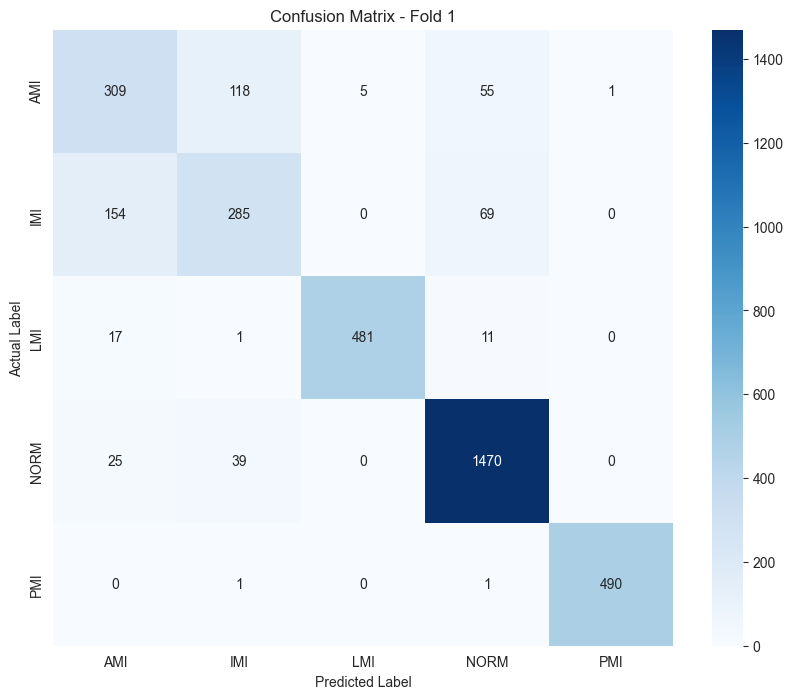

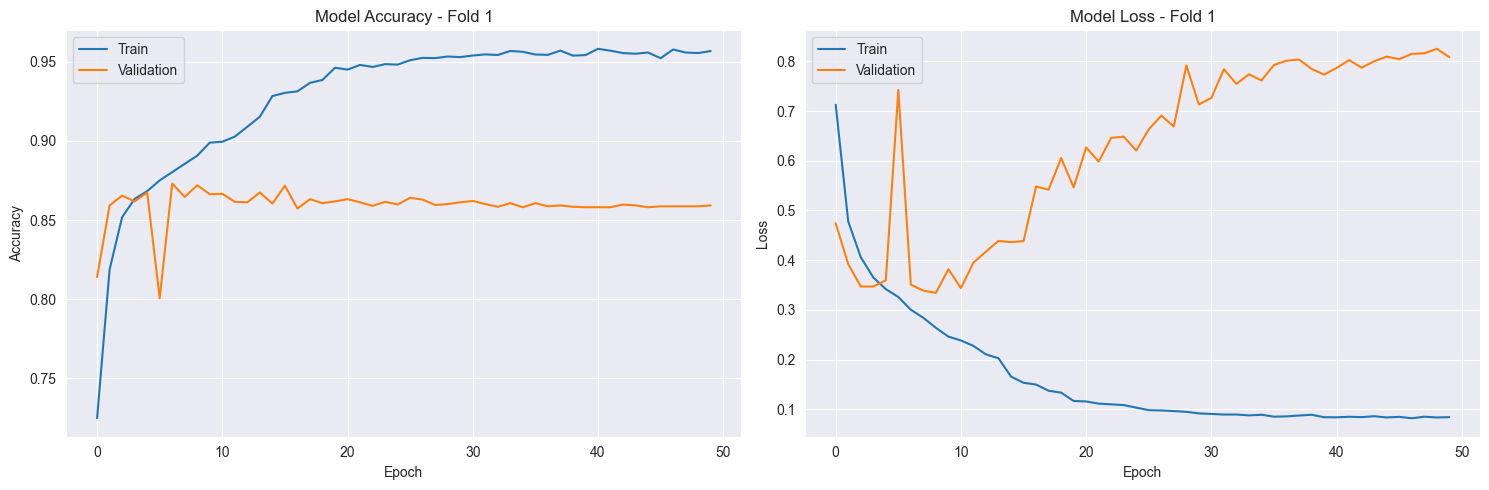


Mulai pelatihan Fold 2/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step

HASIL EVALUASI FOLD 2

Metrics Utama:
Accuracy: 0.8593
Precision: 0.8563
Recall: 0.8593
F1-Score: 0.8571


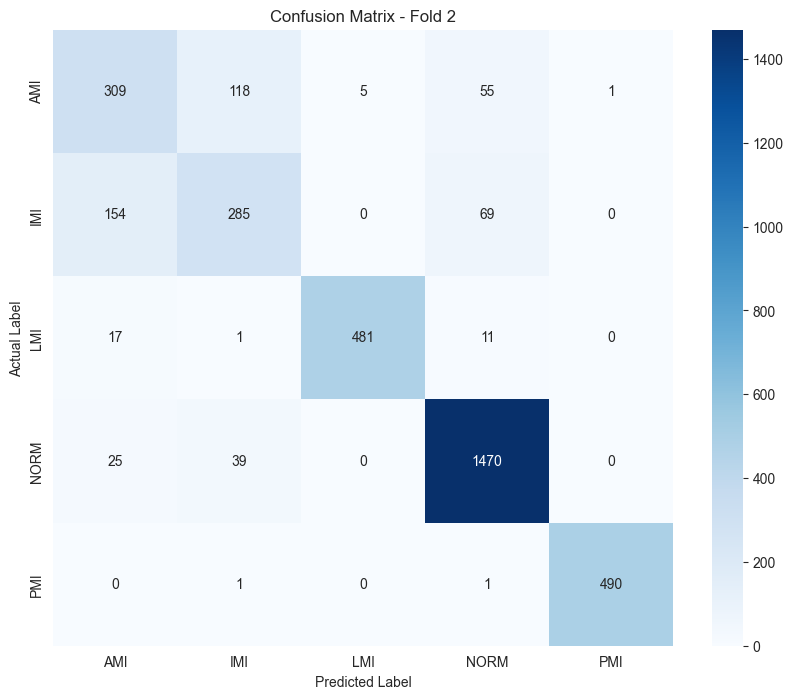

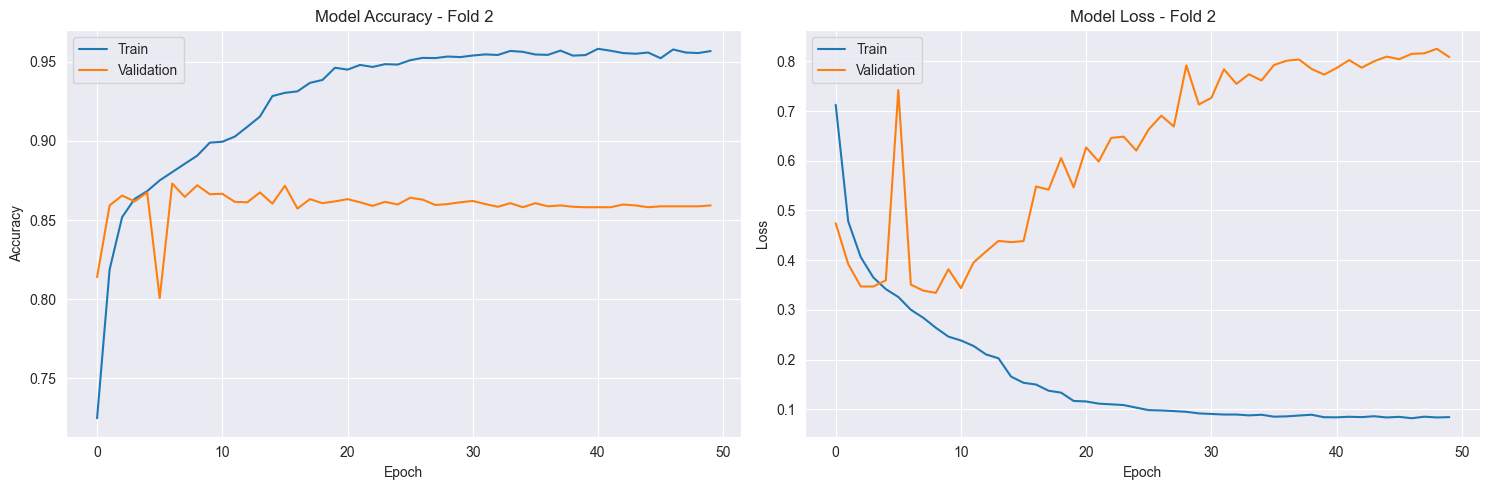


Mulai pelatihan Fold 3/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step

HASIL EVALUASI FOLD 3

Metrics Utama:
Accuracy: 0.8593
Precision: 0.8563
Recall: 0.8593
F1-Score: 0.8571


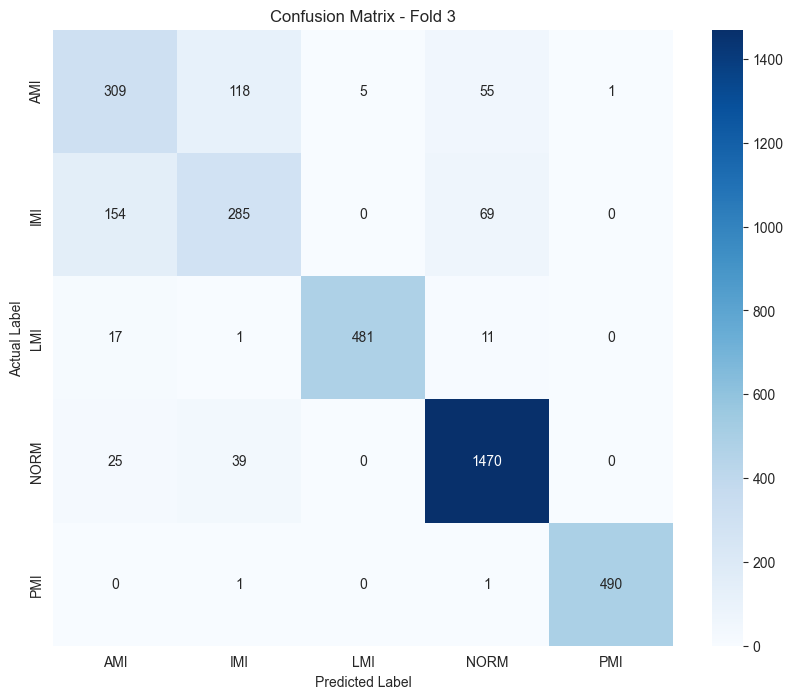

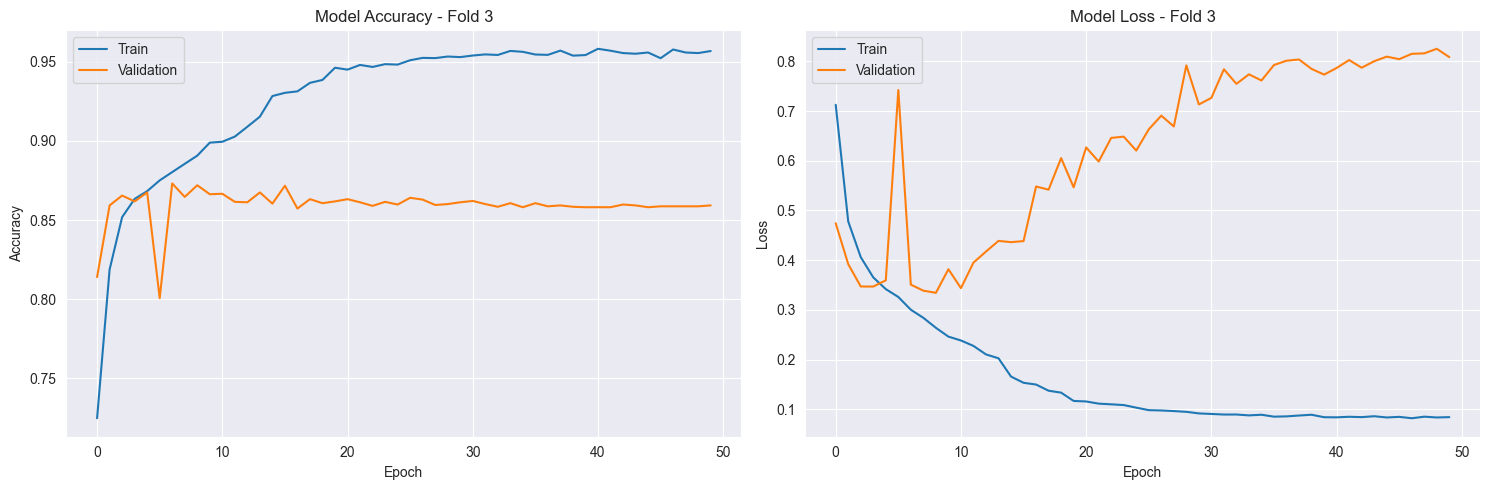


Mulai pelatihan Fold 4/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step

HASIL EVALUASI FOLD 4

Metrics Utama:
Accuracy: 0.8593
Precision: 0.8563
Recall: 0.8593
F1-Score: 0.8571


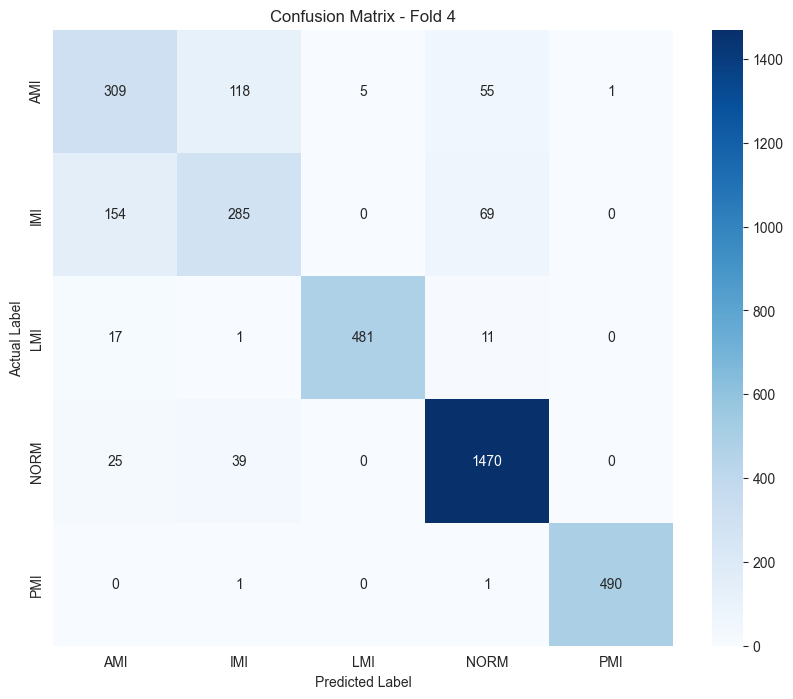

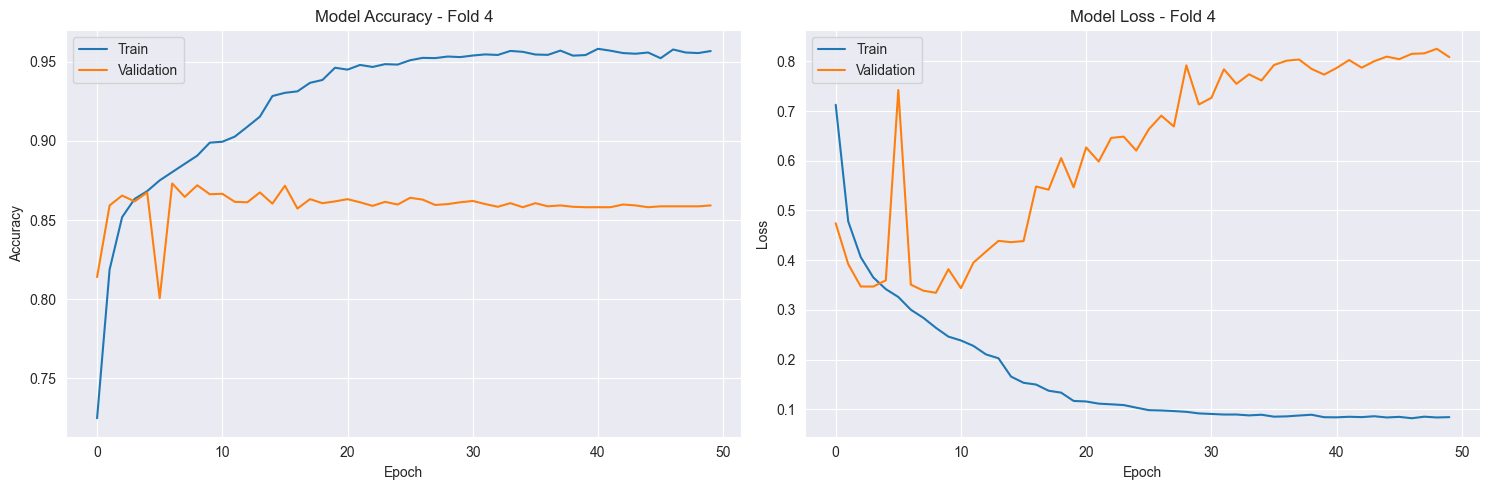


Mulai pelatihan Fold 5/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step

HASIL EVALUASI FOLD 5

Metrics Utama:
Accuracy: 0.8593
Precision: 0.8563
Recall: 0.8593
F1-Score: 0.8571


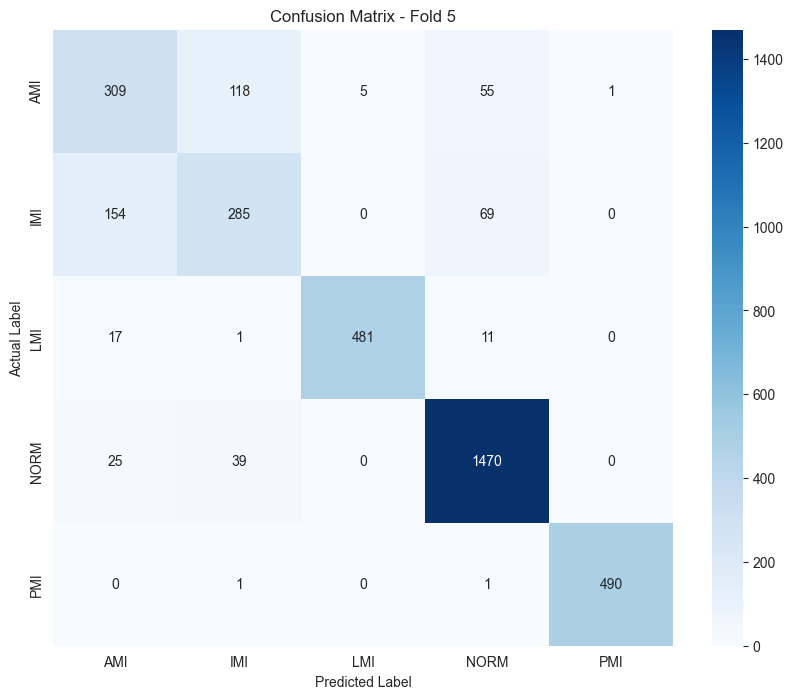

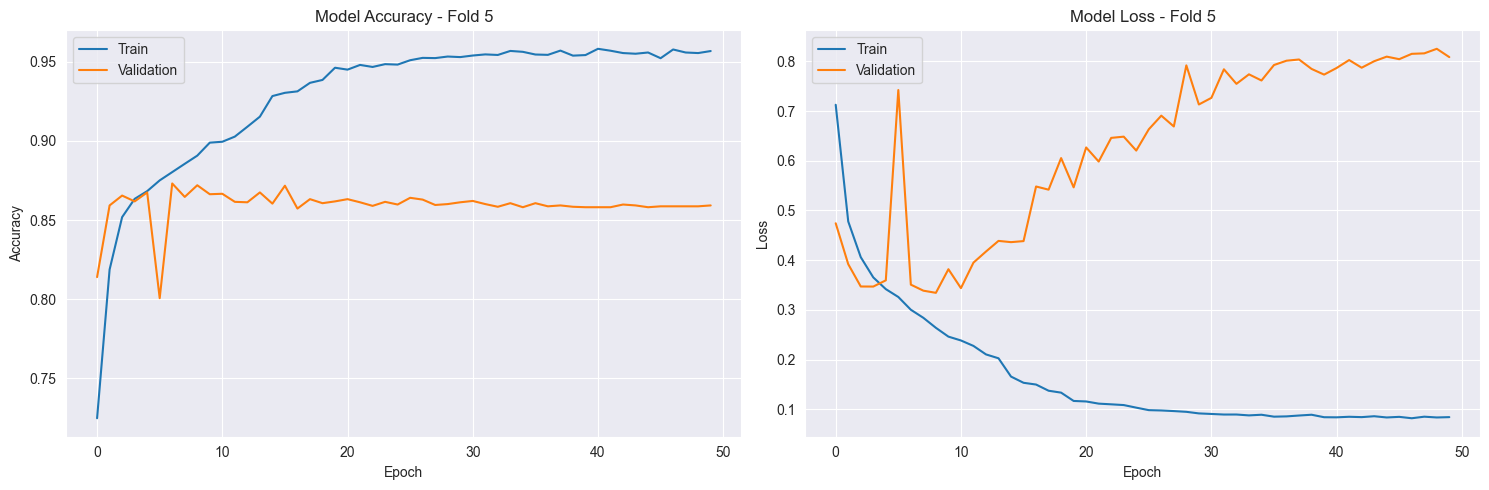


RINGKASAN HASIL K-FOLD CROSS VALIDATION

Hasil per Fold:
   Fold  Accuracy  Precision   Recall  F1-Score
      1  0.854515   0.849000 0.854515  0.850934
      2  0.849703   0.844943 0.849703  0.846590
      3  0.846023   0.841224 0.846023  0.842689
      4  0.859892   0.855877 0.859892  0.857418
      5  0.859287   0.856321 0.859287  0.857093
Average  0.853884   0.849473 0.853884  0.850945


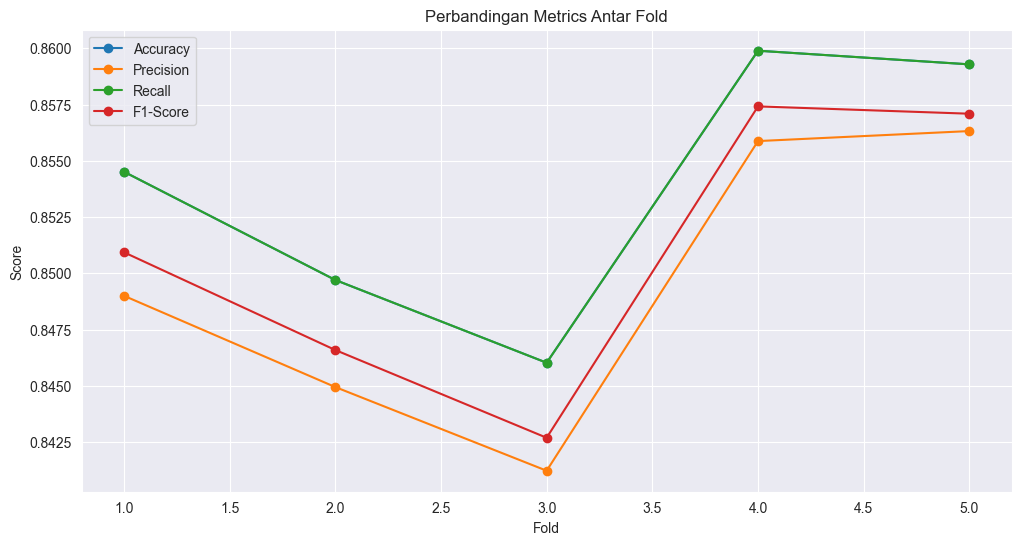


Rata-rata dan Standar Deviasi Metrics:
Accuracy:
  Mean: 0.8539
  Std:  0.0060
Precision:
  Mean: 0.8495
  Std:  0.0066
Recall:
  Mean: 0.8539
  Std:  0.0060
F1-Score:
  Mean: 0.8509
  Std:  0.0065


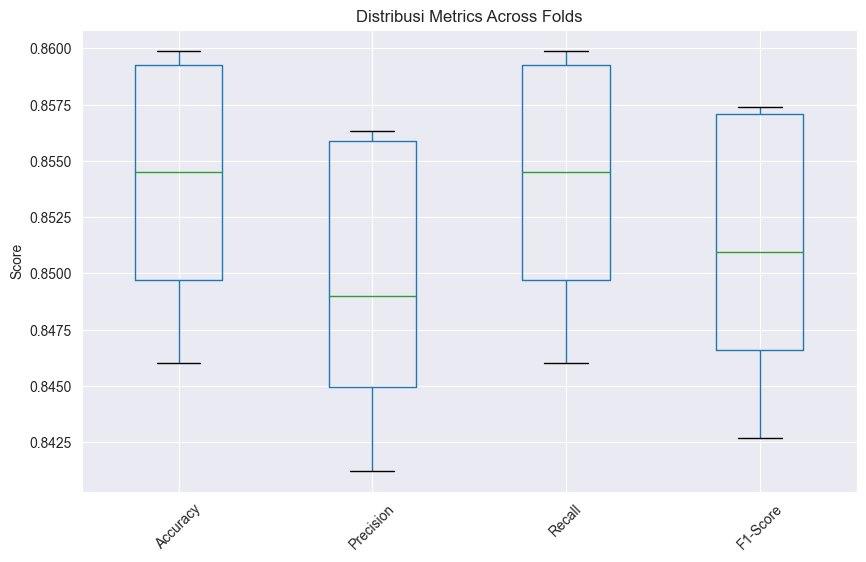


HASIL MODEL FINAL
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step

HASIL EVALUASI FOLD Final

Metrics Utama:
Accuracy: 0.8508
Precision: 0.8481
Recall: 0.8508
F1-Score: 0.8488


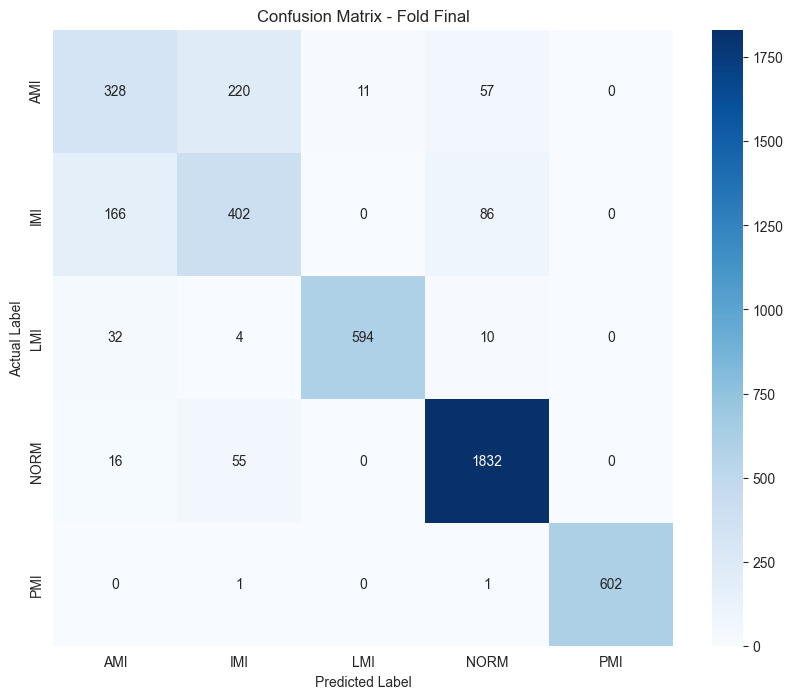

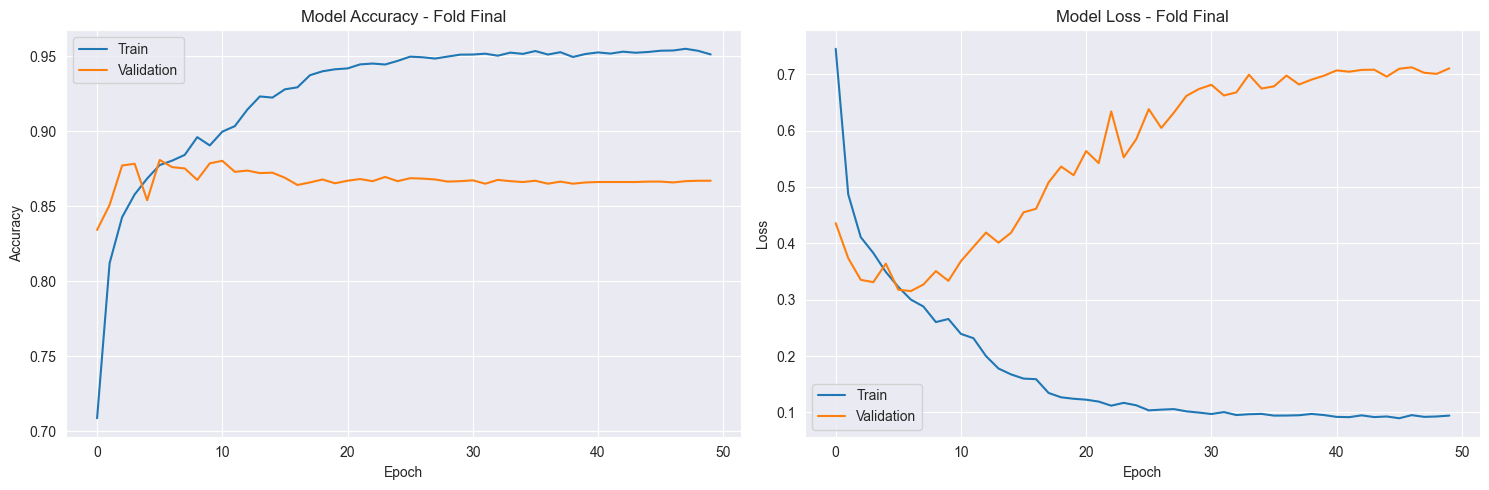

In [14]:
def display_fold_results(fold_num, metrics, cm, class_names, history):
    """
    Fungsi untuk menampilkan hasil evaluasi setiap fold
    """
    print(f"\n{'='*50}")
    print(f"HASIL EVALUASI FOLD {fold_num}")
    print(f"{'='*50}")
    
    # Tampilkan metrics utama
    print("\nMetrics Utama:")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1-Score: {metrics['f1']:.4f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f'Confusion Matrix - Fold {fold_num}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # Plot training history
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot accuracy
    ax1.plot(history['accuracy'])
    ax1.plot(history['val_accuracy'])
    ax1.set_title(f'Model Accuracy - Fold {fold_num}')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend(['Train', 'Validation'])
    
    # Plot loss
    ax2.plot(history['loss'])
    ax2.plot(history['val_loss'])
    ax2.set_title(f'Model Loss - Fold {fold_num}')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend(['Train', 'Validation'])
    
    plt.tight_layout()
    plt.show()
    
    # Tampilkan metrics per kelas
    #print("\nMetrics per Kelas:")
    #for metrics in per_class_metrics:
        #print(f"\nKelas: {metrics['Class']}")
        #print(f"True Positives (TP): {metrics['True Positives']}")
        #print(f"True Negatives (TN): {metrics['True Negatives']}")
        #print(f"False Positives (FP): {metrics['False Positives']}")
        #print(f"False Negatives (FN): {metrics['False Negatives']}")
        #print(f"Precision: {metrics['Precision']:.4f}")
        #print(f"Recall: {metrics['Recall']:.4f}")
        #print(f"F1-Score: {metrics['F1-Score']:.4f}")
        #print(f"Specificity: {metrics['Specificity']:.4f}")

# Dalam loop K-Fold, tambahkan:
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train)):
    fold_num = fold + 1
    print(f'\nMulai pelatihan Fold {fold_num}/{n_folds}')
    
    # ... kode training model ...
    
    # Setelah evaluasi, tampilkan hasil
    fold_metrics = evaluate_model(model, X_val_fold, y_val_fold, le.classes_, fold_num, fold_dir)
    display_fold_results(fold_num, 
                        fold_metrics,
                        fold_metrics['confusion_matrix'],
                        le.classes_,
                        history.history)
    
    fold_results.append(fold_metrics)
    fold_histories.append(history.history)

# Setelah semua fold selesai, tampilkan ringkasan
print("\n" + "="*50)
print("RINGKASAN HASIL K-FOLD CROSS VALIDATION")
print("="*50)

# Tampilkan tabel hasil
print("\nHasil per Fold:")
print(kfold_results_df.to_string(index=False))

# Plot perbandingan metrics antar fold
plt.figure(figsize=(12, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for metric in metrics:
    plt.plot(range(1, n_folds + 1), 
             kfold_results_df[metric][:n_folds], 
             marker='o', 
             label=metric)
plt.title('Perbandingan Metrics Antar Fold')
plt.xlabel('Fold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

# Tampilkan rata-rata dan standar deviasi
print("\nRata-rata dan Standar Deviasi Metrics:")
metrics_mean = kfold_results_df.iloc[:-1][metrics].mean()
metrics_std = kfold_results_df.iloc[:-1][metrics].std()

for metric in metrics:
    print(f"{metric}:")
    print(f"  Mean: {metrics_mean[metric]:.4f}")
    print(f"  Std:  {metrics_std[metric]:.4f}")

# Box plot untuk visualisasi distribusi metrics
plt.figure(figsize=(10, 6))
kfold_results_df.iloc[:-1][metrics].boxplot()
plt.title('Distribusi Metrics Across Folds')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.show()

# Untuk model final
print("\n" + "="*50)
print("HASIL MODEL FINAL")
print("="*50)

final_results = evaluate_model(final_model, X_test, y_test_cat, le.classes_, 'Final', final_dir)
display_fold_results('Final', 
                    final_results,
                    final_results['confusion_matrix'],
                    le.classes_,
                    final_history.history)